# a) Planeje um experimento na sua área de atuação no delineamento quadrado latino.

Tratamentos:

A: Irrigação com Déficit Controlado (60% da ETc)

B: Irrigação Padrão (100% da ETc)

C: Irrigação por Pulsos (100% da ETc, aplicada em frações durante o dia)

D: Irrigação com Excesso (140% da ETc)

E: Irrigação Padrão (100% da ETc) + Hidrogel no solo

Estrutura do Experimento: Um Quadrado Latino 5x5 (25 parcelas).

Variável Resposta: Produtividade de pimentão (ton/ha).

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

dados = {
    'produtividade': [
        28.5, 35.1, 34.8, 30.1, 38.2,  # Linha 1
        34.5, 33.9, 29.5, 37.5, 27.9,  # Linha 2
        33.1, 28.9, 36.9, 27.1, 34.1,  # Linha 3
        28.1, 36.5, 26.5, 33.5, 32.5,  # Linha 4
        35.5, 25.9, 32.9, 31.9, 28.8   # Linha 5
    ],
    'tratamento': [ # Tratamentos conforme o croqui 5x5
        'A_Deficit', 'B_Padrao', 'C_Pulsos', 'D_Excesso', 'E_Hidrogel',
        'B_Padrao', 'C_Pulsos', 'D_Excesso', 'E_Hidrogel', 'A_Deficit',
        'C_Pulsos', 'D_Excesso', 'E_Hidrogel', 'A_Deficit', 'B_Padrao',
        'D_Excesso', 'E_Hidrogel', 'A_Deficit', 'B_Padrao', 'C_Pulsos',
        'E_Hidrogel', 'A_Deficit', 'B_Padrao', 'C_Pulsos', 'D_Excesso'
    ],
    'linha': [ # Fator de bloco 1 (Declividade)
        1, 1, 1, 1, 1,
        2, 2, 2, 2, 2,
        3, 3, 3, 3, 3,
        4, 4, 4, 4, 4,
        5, 5, 5, 5, 5
    ],
    'coluna': [ # Fator de bloco 2 (Solo)
        1, 2, 3, 4, 5,
        1, 2, 3, 4, 5,
        1, 2, 3, 4, 5,
        1, 2, 3, 4, 5,
        1, 2, 3, 4, 5
    ]
}

df = pd.DataFrame(dados)

print("--- Tabela de Dados do Experimento (5x5) ---")
df

In [10]:
df.to_csv(r"G:\Meu Drive\Doutorado_Esalq\estatistica_exp\arquivos\dql.csv", index=False)

In [2]:
import pandas as pd
import numpy as np
irrigacao = ['60%', '80%', '100%']  # Parcela
adubacao = ['50', '100', '150']     # Subparcela
blocos = [f'B{i+1}' for i in range(4)]

# Médias hipotéticas (em kg/ha)
media_base = {
    ('60%', '50'): 2800,
    ('60%', '100'): 3200,
    ('60%', '150'): 3400,
    ('80%', '50'): 3200,
    ('80%', '100'): 3600,
    ('80%', '150'): 3900,
    ('100%', '50'): 3500,
    ('100%', '100'): 4000,
    ('100%', '150'): 4200,
}

# Simulando os dados
np.random.seed(42)
dados = []
for bloco in blocos:
    for irr in irrigacao:
        for adubo in adubacao:
            media = media_base[(irr, adubo)]
            produtividade = np.random.normal(loc=media, scale=100)
            dados.append({
                'Bloco': bloco,
                'Irrigacao': irr,
                'Adubacao': adubo,
                'Produtividade': round(produtividade, 1)
            })

# Criar DataFrame
df = pd.DataFrame(dados)
df.to_csv(r"G:\Meu Drive\Doutorado_Esalq\estatistica_exp\arquivos\parcela_sub.csv", index=False)

---
# Anova

In [5]:
modelo = ols('produtividade ~ C(tratamento) + C(linha) + C(coluna)', data=df).fit()
tabela_anova = sm.stats.anova_lm(modelo, typ=2)
print("--- Tabela da Análise de Variância (ANOVA) ---")
print(tabela_anova)

--- Tabela da Análise de Variância (ANOVA) ---
                 sum_sq    df           F        PR(>F)
C(tratamento)  307.7224   4.0  950.542834  6.770357e-15
C(linha)        17.6464   4.0   54.509061  1.347540e-07
C(coluna)        0.3664   4.0    1.131796  3.873294e-01
Residual         0.9712  12.0         NaN           NaN


---
## Tukey

In [6]:
# --- 3. Teste de Comparações Múltiplas (Tukey HSD) ---
tukey_resultado = pairwise_tukeyhsd(endog=df['produtividade'], groups=df['tratamento'], alpha=0.05)

print("--- Teste de Tukey HSD para as Estratégias de Irrigação ---")
print(tukey_resultado)
print("\n")

--- Teste de Tukey HSD para as Estratégias de Irrigação ---
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2   meandiff p-adj   lower   upper  reject
-----------------------------------------------------------
A_Deficit   B_Padrao     6.84    0.0  4.9962  8.6838   True
A_Deficit   C_Pulsos     6.06    0.0  4.2162  7.9038   True
A_Deficit  D_Excesso      1.9 0.0414  0.0562  3.7438   True
A_Deficit E_Hidrogel     9.74    0.0  7.8962 11.5838   True
 B_Padrao   C_Pulsos    -0.78 0.7141 -2.6238  1.0638  False
 B_Padrao  D_Excesso    -4.94    0.0 -6.7838 -3.0962   True
 B_Padrao E_Hidrogel      2.9 0.0011  1.0562  4.7438   True
 C_Pulsos  D_Excesso    -4.16    0.0 -6.0038 -2.3162   True
 C_Pulsos E_Hidrogel     3.68 0.0001  1.8362  5.5238   True
D_Excesso E_Hidrogel     7.84    0.0  5.9962  9.6838   True
-----------------------------------------------------------




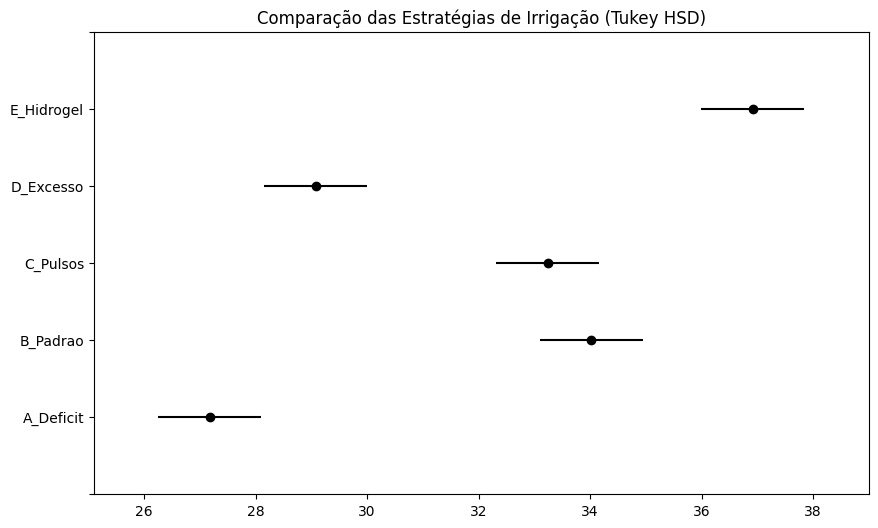

In [7]:
tukey_resultado.plot_simultaneous()
plt.title('Comparação das Estratégias de Irrigação (Tukey HSD)')
plt.show()